# An Anomaly Detection Project in S&P500 Stocks by Upamanyu Moitra, PhD

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
import yfinance as yf

In [3]:
tickers = ["SPY", "AAPL", "MSFT", "NVDA", "JPM", "XOM"]

In [4]:
start_date = "2015-01-01"
end_date = "2025-01-01"

In [5]:
data = yf.download(tickers,\
                   start=start_date,\
                   end=end_date,\
                   auto_adjust=True
                   )

[*********************100%***********************]  6 of 6 completed


In [6]:
data.head()

Price           Close                                                         \
Ticker           AAPL        JPM       MSFT      NVDA         SPY        XOM   
Date                                                                           
2015-01-02  24.192604  46.274323  39.681732  0.482423  169.687805  57.145550   
2015-01-05  23.511066  44.837738  39.316837  0.474275  166.623367  55.581951   
2015-01-06  23.513279  43.675133  38.739773  0.459896  165.053970  55.286461   
2015-01-07  23.842981  43.741776  39.231976  0.458697  167.110718  55.846645   
2015-01-08  24.759075  44.719246  40.386105  0.475952  170.076126  56.776211   

Price            High                                  ...       Open  \
Ticker           AAPL        JPM       MSFT      NVDA  ...       MSFT   
Date                                                   ...              
2015-01-02  24.659506  46.622359  40.241825  0.486018  ...  39.596871   
2015-01-05  24.042140  46.118816  39.656286  0.483861  ...  39.350780   
2015-01-06  23.772177  44.985831  39.673260  0.475473  ...  39.359269   
2015-01-07  23.942557  44.348991  39.427159  0.467325  ...  39.019819   
2015-01-08  24.816609  45.096906  40.521885  0.478828  ...  39.673259   

Price                                           Volume                      \
Ticker          NVDA         SPY        XOM       AAPL       JPM      MSFT   
Date                                                                         
2015-01-02  0.482423  170.472527  56.788504  212818400  12600000  27913900   
2015-01-05  0.482423  168.647097  56.696174  257142000  20100600  39673900   
2015-01-06  0.474994  166.929011  55.551166  263188400  29074100  36447900   
2015-01-07  0.463251  166.375567  55.803554  160423600  23843200  29114100   
2015-01-08  0.463970  168.514962  56.172927  237458000  16971100  29645200   

Price                                       
Ticker           NVDA        SPY       XOM  
Date                                        
2015-01-02  113680000  121465900  10220400  
2015-01-05  197952000  169632600  18502400  
2015-01-06  197764000  209151400  16670700  
2015-01-07  321808000  125346700  13590700  
2015-01-08  283780000  147217800  15487500  

[5 rows x 30 columns]

In [7]:
close_prices = data["Close"]

In [ ]:
close_prices.head()

Ticker,AAPL,JPM,MSFT,NVDA,SPY,XOM
Date,,,,,,
2015-01-02,24.192600,46.274315,39.681747,0.482985,170.124969,57.145542
2015-01-05,23.511061,44.837727,39.316845,0.474828,167.052643,55.581940
2015-01-06,23.513275,43.675133,38.739765,0.460432,165.479202,55.286449
2015-01-07,23.842978,43.741779,39.231964,0.459232,167.541199,55.846645
2015-01-08,24.759071,44.719250,40.386108,0.476507,170.514252,56.776192


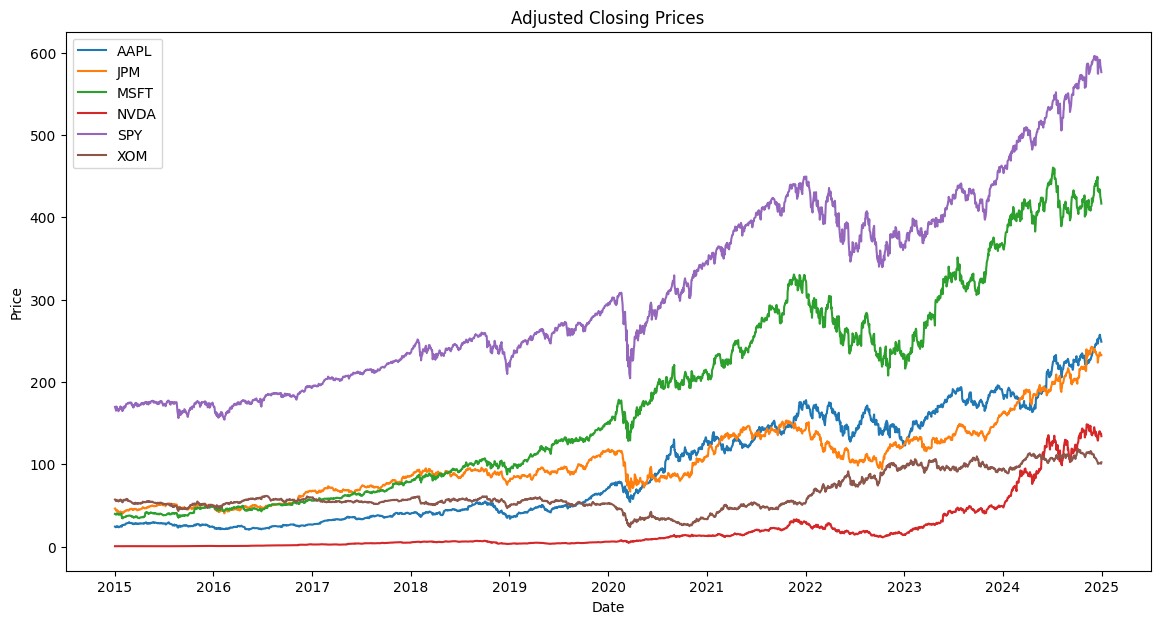

In [8]:
plt.figure(figsize=(14, 7))
for ticker in close_prices.columns:
    plt.plot(
        close_prices.index,
        close_prices[ticker],
        label=ticker
    )
plt.title("Adjusted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [9]:
close_prices.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=2516, freq=None)

In [10]:
close_prices.shift(1)

Ticker,AAPL,JPM,MSFT,NVDA,SPY,XOM
Date,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,24.192604,46.274323,39.681732,0.482423,169.687805,57.145550
2015-01-06,23.511066,44.837738,39.316837,0.474275,166.623367,55.581951
2015-01-07,23.513279,43.675133,38.739773,0.459896,165.053970,55.286461
2015-01-08,23.842981,43.741776,39.231976,0.458697,167.110718,55.846645
...,...,...,...,...,...,...
2024-12-24,253.649429,231.216522,430.147217,139.461716,584.680298,101.171143
2024-12-26,256.560822,235.018585,434.179352,140.010895,591.179077,101.266319
2024-12-27,257.375610,235.823624,432.973663,139.721313,591.218445,101.351982


In the following I compute the log returns

In [11]:
log_returns = np.log(close_prices / close_prices.shift(1))
log_returns = log_returns.dropna()
log_returns.head()

Ticker,AAPL,JPM,MSFT,NVDA,SPY,XOM
Date,,,,,,
2015-01-05,-0.028576,-0.031537,-0.009238,-0.017034,-0.018224,-0.027743
2015-01-06,0.000094,-0.026271,-0.014786,-0.030787,-0.009463,-0.005330
2015-01-07,0.013925,0.001525,0.012625,-0.002609,0.012384,0.010081
2015-01-08,0.037702,0.022100,0.028994,0.036927,0.017590,0.016508
2015-01-09,0.001072,-0.017540,-0.008441,0.004020,-0.008046,-0.001411


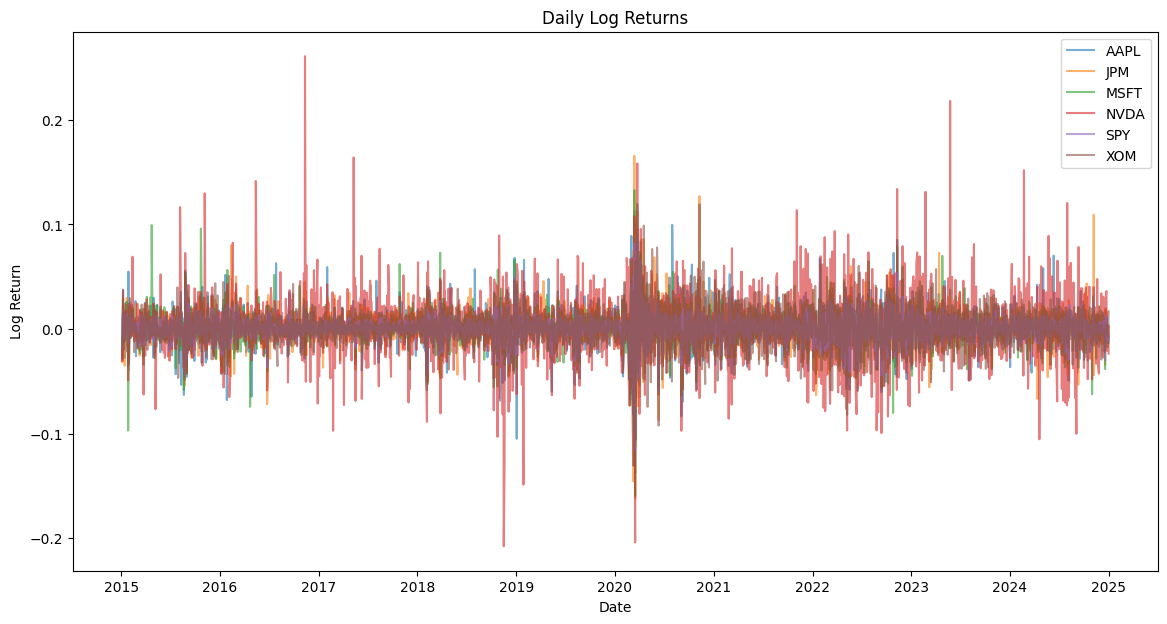

In [12]:
plt.figure(figsize=(14, 7))
for ticker in close_prices.columns:
    plt.plot(
        log_returns.index,
        log_returns[ticker],
        alpha = 0.6,
        label=ticker
    )
plt.title("Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.show()

### Rolling Volatility

In [13]:
rolling_volatility = log_returns.rolling(window=21).std()* np.sqrt(252)

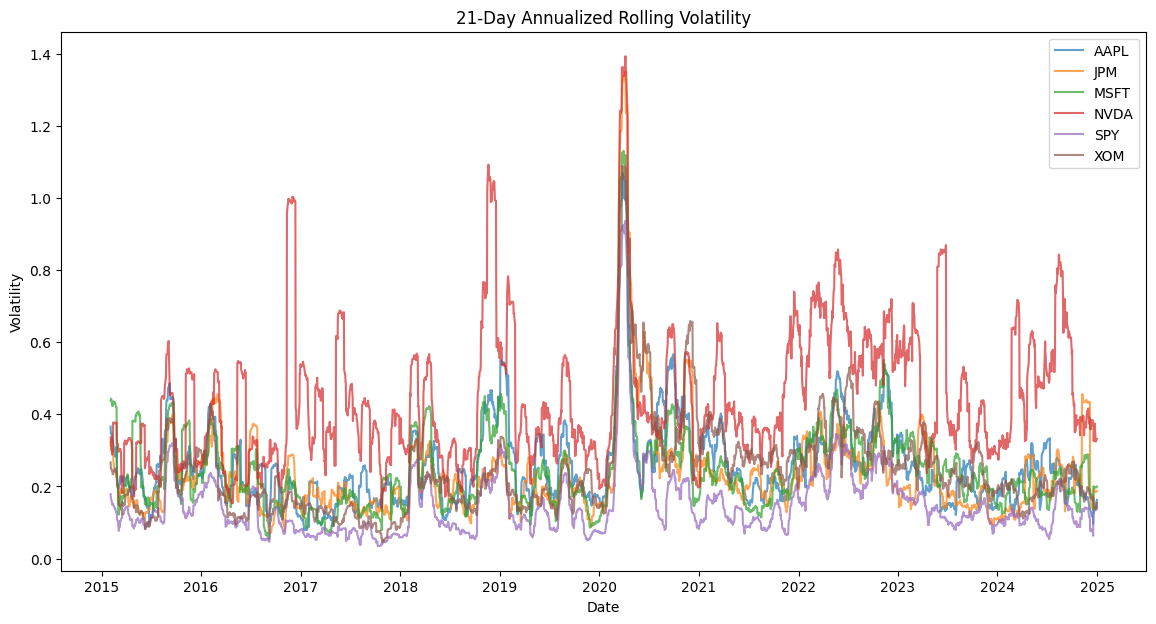

In [14]:
plt.figure(figsize=(14, 7))
for ticker in rolling_volatility.columns:
    plt.plot(
        rolling_volatility.index,
        rolling_volatility[ticker],
        alpha = 0.7,
        label=ticker
    )

plt.title("21-Day Annualized Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

## Anomakly Detection Tool

In [15]:
def anomalous_zscore(returns, window = 21, threshold = 3):
  rolling_mean = returns.rolling(window).mean()
  rolling_std  = returns.rolling(window).std()

  z_score = (returns - rolling_mean)/rolling_std

  anomalous = z_score.abs() > threshold

  results = pd.DataFrame({
      "returns": returns,
      "z_score": z_score,
      "anomaly": anomalous
  })

  return results

Let us now focus on the NVDA results -- it stands apart from the others in the plots above

In [16]:
nvda_results = anomalous_zscore(log_returns['NVDA'], window = 42, threshold=3)
nvda_results.tail()

,returns,z_score,anomaly
Date,,,
2024-12-24,0.003930,0.171770,False
2024-12-26,-0.002070,-0.078162,False
2024-12-27,-0.021088,-0.882120,False
2024-12-30,0.003497,0.178228,False
2024-12-31,-0.023549,-0.968811,False


In [17]:
nvda_anomalies = nvda_results[nvda_results["anomaly"]]
nvda_anomalies.head()

,returns,z_score,anomaly
Date,,,
2015-05-08,-0.076677,-3.646088,True
2015-08-07,0.116642,5.043180,True
2015-11-06,0.129780,4.884715,True
2016-02-18,0.082542,3.036082,True
2016-05-13,0.141582,5.378101,True


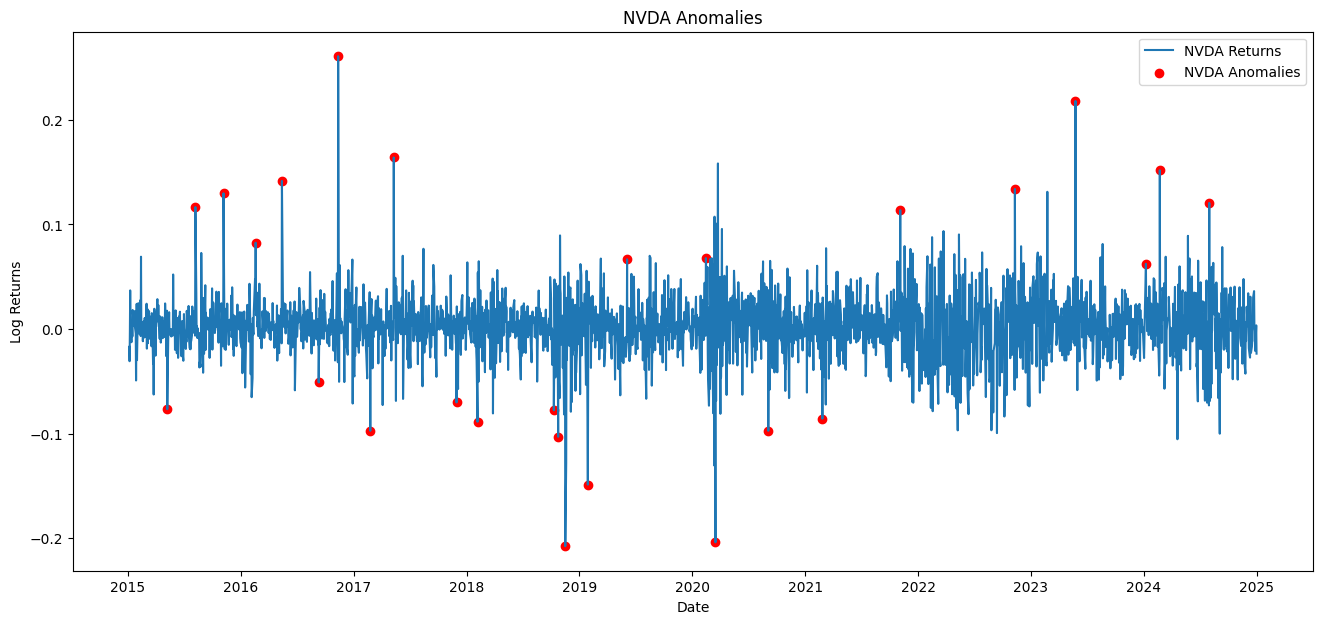

In [20]:
plt.figure(figsize=(16, 7))
plt.plot(
    nvda_results.index,
    nvda_results["returns"],
    label="NVDA Returns"
)
plt.scatter(
    nvda_anomalies.index,
    nvda_anomalies["returns"],
    label="NVDA Anomalies",
    color = 'r'
)
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.title("NVDA Anomalies")
plt.legend()
plt.show()

Some of the apparent spikes are missed when the rolling window is 1-month (21 days). With a 42-day rolling window, the effect of Covid is clearly observed.

## The z-scores

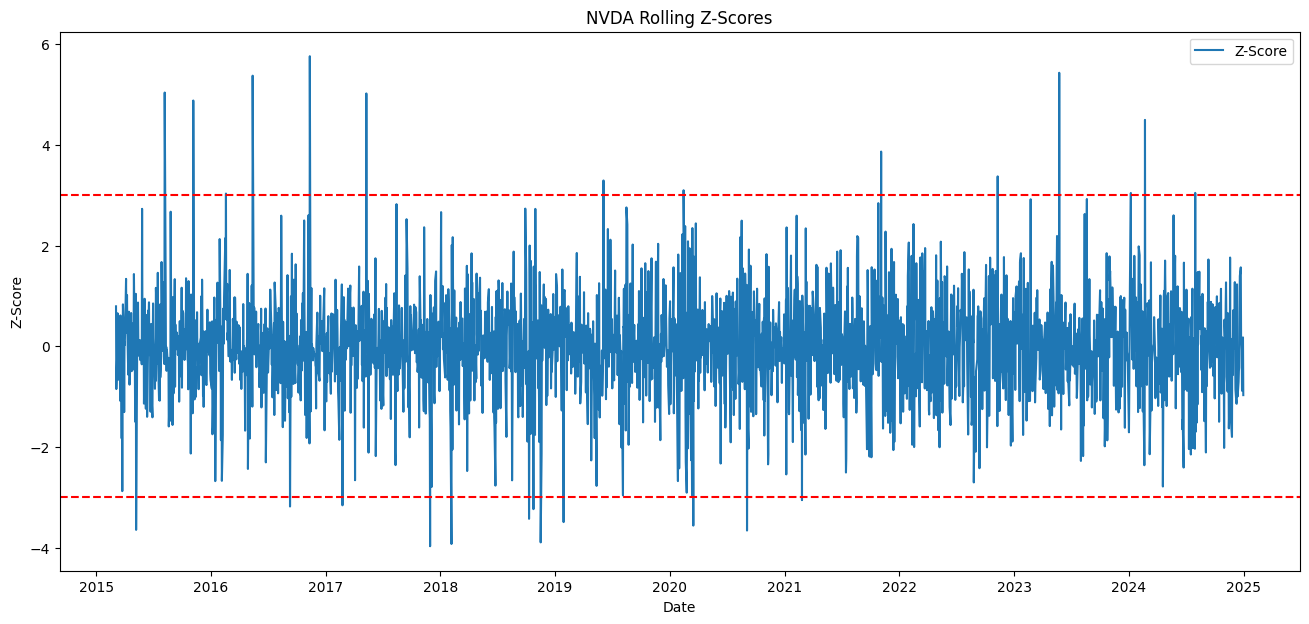

In [21]:
plt.figure(figsize=(16, 7))
plt.plot(
    nvda_results.index,
    nvda_results["z_score"],
    label="Z-Score"
)
plt.axhline(
    +3,
    linestyle="--",
    color = 'r'
)
plt.axhline(
    -3,
    linestyle="--",
    color = 'r'
)
plt.title("NVDA Rolling Z-Scores")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend()
plt.show()


## Summary of the Anomalies


In [22]:
summary = {}
for ticker in log_returns.columns:
    results = anomalous_zscore(log_returns[ticker], window = 42, threshold=3)
    n_anomalies = results["anomaly"].sum()
    summary[ticker] = n_anomalies

In [23]:
summary

{'AAPL': np.int64(35),
 'JPM': np.int64(29),
 'MSFT': np.int64(24),
 'NVDA': np.int64(26),
 'SPY': np.int64(36),
 'XOM': np.int64(21)}

In [24]:
summary_df = pd.DataFrame.from_dict(summary,\
                                    orient="index",
                                    columns=["Anomaly Count"]
                                    )

In [25]:
summary_df.sort_values(by="Anomaly Count", ascending=False)

,Anomaly Count
SPY,36
AAPL,35
JPM,29
NVDA,26
MSFT,24
XOM,21


# Applying Machine Learning

In [26]:
volume_data = data["Volume"]
volume_data.head()

Ticker,AAPL,JPM,MSFT,NVDA,SPY,XOM
Date,,,,,,
2015-01-02,212818400,12600000,27913900,113680000,121465900,10220400
2015-01-05,257142000,20100600,39673900,197952000,169632600,18502400
2015-01-06,263188400,29074100,36447900,197764000,209151400,16670700
2015-01-07,160423600,23843200,29114100,321808000,125346700,13590700
2015-01-08,237458000,16971100,29645200,283780000,147217800,15487500


### Making Features

In [27]:
def make_features(close_prices, volume, window = 21):
  log_returns = np.log(close_prices/close_prices.shift(1) )

  rolling_volatility = log_returns.rolling(window).std()*np.sqrt(252)

  rolling_mean = log_returns.rolling(window).mean()

  momentum = close_prices/close_prices.shift(window)

  volume_change = volume.pct_change()

  features = pd.DataFrame(
      {"log_returns": log_returns,\
       "rolling_volatility": rolling_volatility,\
       "rolling_mean": rolling_mean,\
       "momentum": momentum,\
       "volume_change": volume_change
       }
  )

  return features.dropna()

In [28]:
nvda_features = make_features(close_prices['NVDA'], volume_data['NVDA'], window = 42)

In [29]:
nvda_features.head()

,log_returns,rolling_volatility,rolling_mean,momentum,volume_change
Date,,,,,
2015-03-05,0.018989,0.316706,0.003120,1.139991,0.424158
2015-03-06,-0.013653,0.315489,0.003200,1.143852,-0.203259
2015-03-09,0.002657,0.303763,0.003996,1.182755,-0.135995
2015-03-10,0.017101,0.304963,0.004466,1.206299,1.370685
2015-03-11,-0.005231,0.294692,0.003462,1.156501,-0.502819


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [31]:
def iso_forest(features, contamination = 0.02, n_estimators = 200, \
               random_state = 137):
  """
  A pipeline for isolation forest
  """
  scaler = StandardScaler()
  features_scaled = scaler.fit_transform(features)
  model = IsolationForest(n_estimators=n_estimators,\
                          contamination = contamination,\
                          random_state = random_state)
  model.fit(features_scaled)
  predictions = model.predict(features_scaled)
  scores = model.decision_function(features_scaled)
  results = features.copy()

  results["anomaly"] = predictions
  results["score"] = scores

  return results

In [32]:
nvda_results_pl = iso_forest(features = nvda_features, n_estimators = 200)

In [33]:
nvda_anomalies_pl = nvda_results_pl[ nvda_results_pl['anomaly'] == -1]
nvda_anomalies_pl.head()

,log_returns,rolling_volatility,rolling_mean,momentum,volume_change,anomaly,score
Date,,,,,,,
2015-11-06,0.129780,0.394673,0.008336,1.419253,1.448354,-1,-0.017820
2016-05-13,0.141582,0.400829,0.005785,1.275047,2.147099,-1,-0.021694
2016-06-24,-0.058603,0.441099,0.005442,1.256819,2.416423,-1,-0.013303
2016-11-11,0.260876,0.693712,0.008953,1.456457,1.502466,-1,-0.056425
2016-12-14,0.056299,0.745448,0.009072,1.463774,1.537365,-1,-0.008619


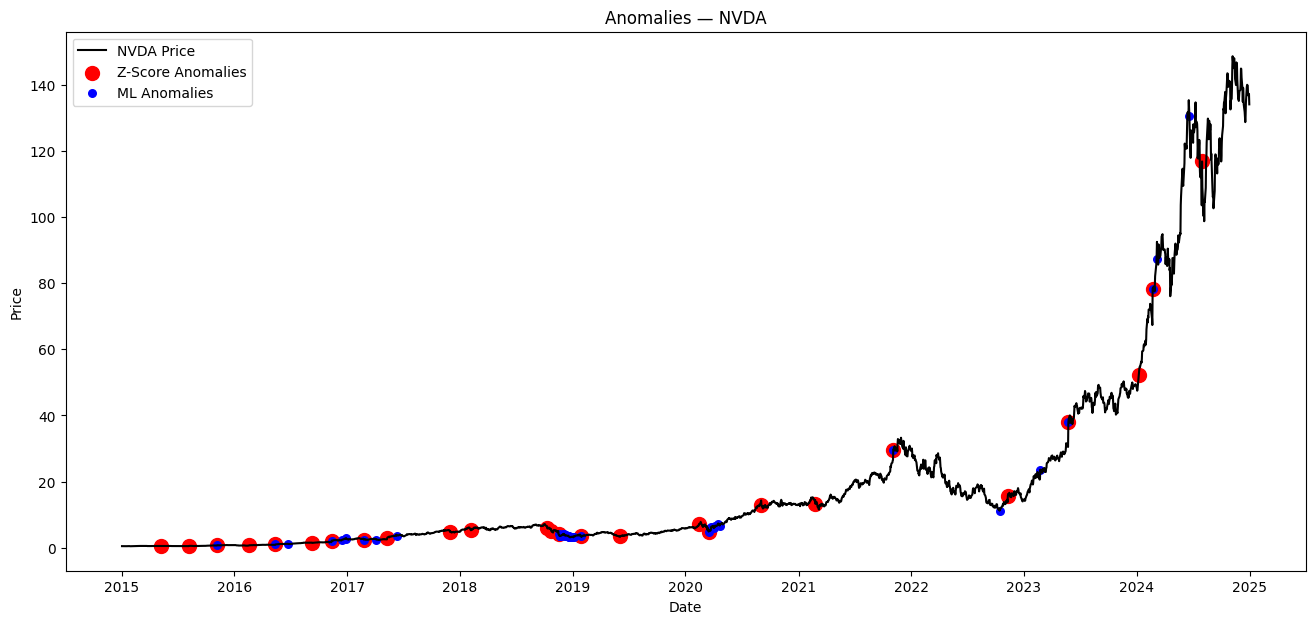

In [34]:
plt.figure(figsize=(16, 7))
plt.plot(
    close_prices["NVDA"],
    label="NVDA Price",
    color = 'black'
)
plt.scatter(
    nvda_anomalies.index,
    close_prices.loc[
        nvda_anomalies.index,
        "NVDA"
    ],
    color="red",
    s=100,
    label="Z-Score Anomalies"
)
plt.scatter(
    nvda_anomalies_pl.index,
    close_prices.loc[
        nvda_anomalies_pl.index,
        "NVDA"],
    color="blue",
    s=30,
    label="ML Anomalies"
)
plt.title("Anomalies — NVDA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

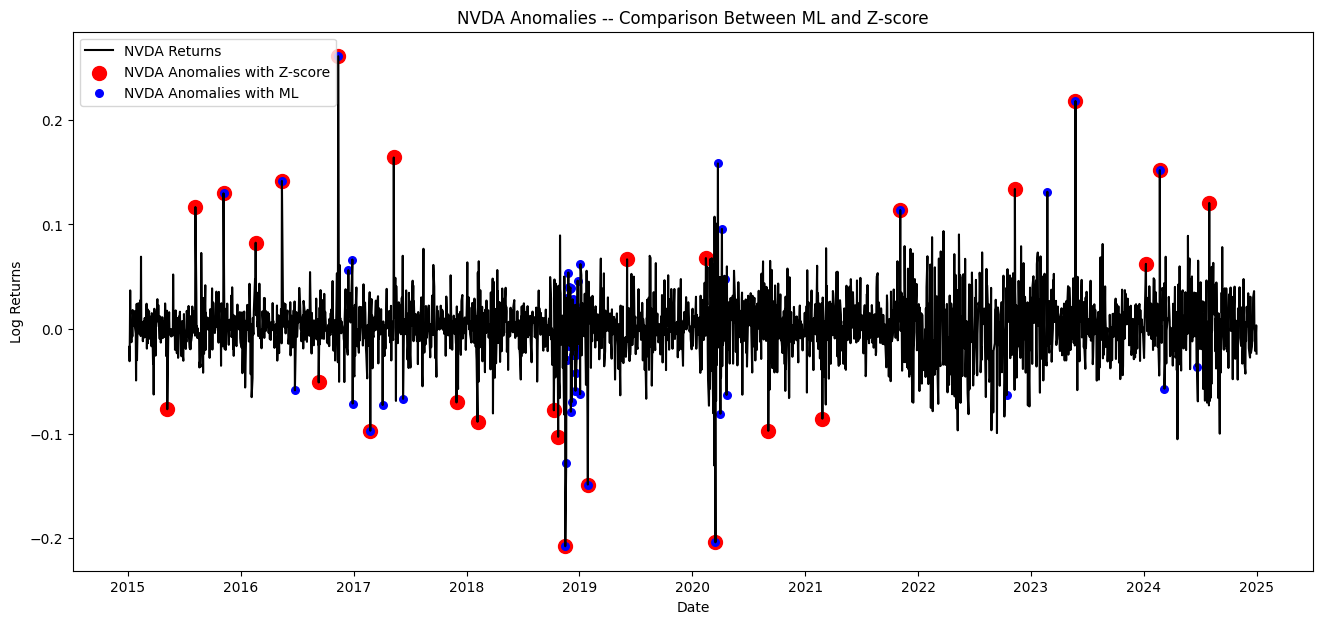

In [35]:
plt.figure(figsize=(16, 7))
plt.plot(
    nvda_results.index,
    nvda_results["returns"],
    label="NVDA Returns",
    color = 'black'
)
plt.scatter(
    nvda_anomalies.index,
    nvda_anomalies["returns"],
    label="NVDA Anomalies with Z-score",
    color = 'r',
    s=100
)

plt.scatter(
    nvda_anomalies_pl.index,
    nvda_anomalies_pl['log_returns'],
    color="blue",
    s=30,
    label="NVDA Anomalies with ML"
)

plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.title("NVDA Anomalies -- Comparison Between ML and Z-score")
plt.legend()
plt.show()
#Machine learning captures the anomalies around COVID much better

## Summary of the Machine Learning

In [36]:
ml_summary = {}
for ticker in tickers:
    feat = make_features(close_prices[ticker],\
                             volume_data[ticker]
                             )
    res = iso_forest(features = feat, n_estimators = 400)
    n_anomalies = (res["anomaly"] == -1).sum()
    ml_summary[ticker] = n_anomalies

In [37]:
ml_summary_df = pd.DataFrame.from_dict(ml_summary,\
                                       orient="index",\
                                       columns=["ML Anomaly Count"]
                                       )

In [38]:
print(ml_summary_df)

      ML Anomaly Count
SPY                 50
AAPL                50
MSFT                50
NVDA                50
JPM                 50
XOM                 50


There are exactly 50 anomalies in each case because of the value of the contamination chosen.

## Some More Visualization

In [39]:
import plotly.graph_objects as go

In [40]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x = log_returns.index,
        y = log_returns["NVDA"],
        mode="lines",
        name="NVDA Log Returns"
    )
)

fig.add_trace(
    go.Scatter(
        x= nvda_anomalies_pl.index,
        y= nvda_anomalies_pl['log_returns'],
        mode="markers",
        name="Anomalies",
        marker=dict(
            size=10,
            symbol="x"
        )
    )
)

fig.update_layout(
    title="NVDA Log Returns with ML-Detected Anomalies",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white",
    height=700
)

fig.show()

## Correlation Matrix for Log Returns

In [41]:
corr_returns = log_returns.corr()

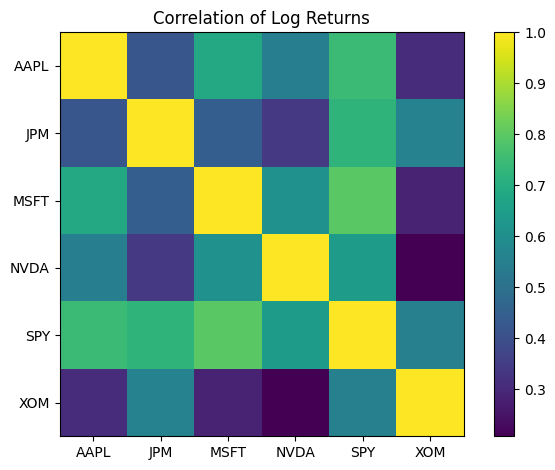

In [42]:
plt.imshow(corr_returns)
plt.title("Correlation of Log Returns")
plt.xticks(range(6), corr_returns.columns)
plt.yticks(range(6), corr_returns.columns)
plt.tight_layout()
plt.colorbar()
plt.show()

## Principal Component Analysis

In [43]:
from sklearn.decomposition import PCA

In [44]:
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(log_returns)

In [45]:
pca = PCA(n_components=2)
p_components = pca.fit_transform(scaled_returns)

In [46]:
exp_variance = pca.explained_variance_ratio_
print(exp_variance)

[0.61540167 0.17200722]


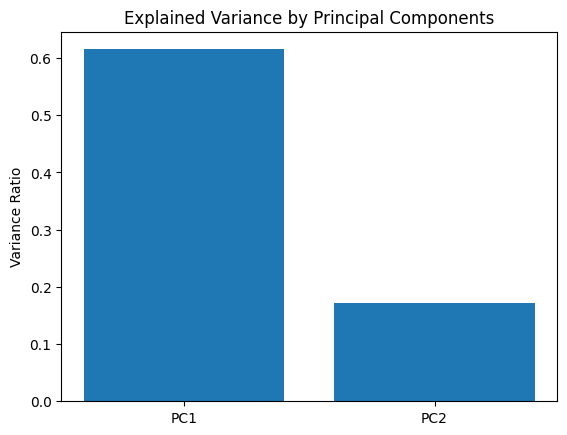

In [47]:
plt.bar(["PC1", "PC2"], exp_variance)
plt.title("Explained Variance by Principal Components")
plt.ylabel("Variance Ratio")
plt.show()

In [48]:
p_components.shape

(2515, 2)

In [49]:
pca_df = pd.DataFrame({
    "PC1": p_components[:,0],\
    "PC2": p_components[:,1]
}, index = log_returns.index)

In [50]:
pca_df.head()

,PC1,PC2
Date,,
2015-01-05,-3.238040,-1.114308
2015-01-06,-1.972928,-0.224584
2015-01-07,1.271426,0.103801
2015-01-08,3.540850,-0.261694
2015-01-09,-1.031203,-0.435850


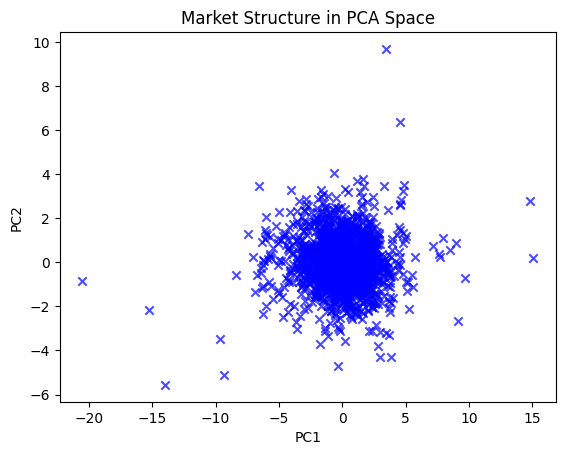

In [51]:
plt.scatter(pca_df["PC1"], pca_df["PC2"],marker = 'x',\
            c = 'blue', alpha = 0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Market Structure in PCA Space")
plt.show()

### Scanning for Outliers

In [52]:
pca_df["distance"] = np.sqrt(pca_df['PC1']**2 + pca_df['PC2']**2)

In [53]:
pca_df.head()

,PC1,PC2,distance
Date,,,
2015-01-05,-3.238040,-1.114308,3.424411
2015-01-06,-1.972928,-0.224584,1.985670
2015-01-07,1.271426,0.103801,1.275656
2015-01-08,3.540850,-0.261694,3.550507
2015-01-09,-1.031203,-0.435850,1.119529


In [54]:
dist_threshold = pca_df['distance'].quantile(0.98)

In [55]:
print(dist_threshold)

5.6692493167158755


In [56]:
pca_df["anomaly"] = (pca_df['distance'] > dist_threshold)

In [57]:
pca_ano = pca_df[pca_df['anomaly']]
pca_nano = pca_df[~pca_df['anomaly']]

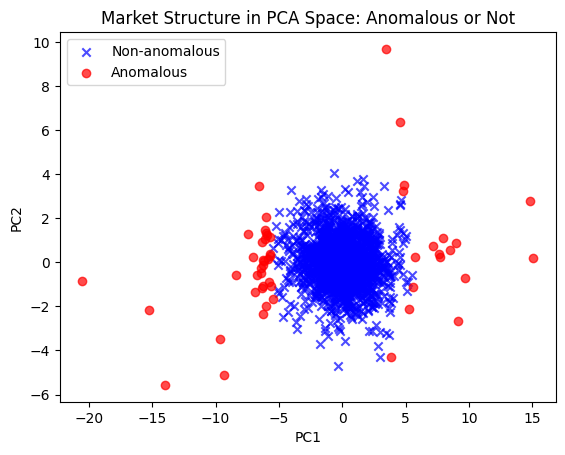

In [58]:
plt.scatter(pca_nano["PC1"], pca_nano["PC2"],marker = 'x',\
            c = 'blue', alpha = 0.7, label = 'Non-anomalous')
plt.scatter(pca_ano["PC1"], pca_ano["PC2"],marker = 'o',\
            c = 'red', alpha = 0.7, label = 'Anomalous')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Market Structure in PCA Space: Anomalous or Not")
plt.legend(loc = 'upper left')
plt.show()

In [60]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns = ["PC1", "PC2"],
    index = log_returns.columns
)

In [61]:
pca_loadings

,PC1,PC2
Ticker,,
AAPL,0.421101,-0.265419
JPM,0.382666,0.461245
MSFT,0.436279,-0.302247
NVDA,0.375377,-0.413163
SPY,0.501388,0.032191
XOM,0.305948,0.673582


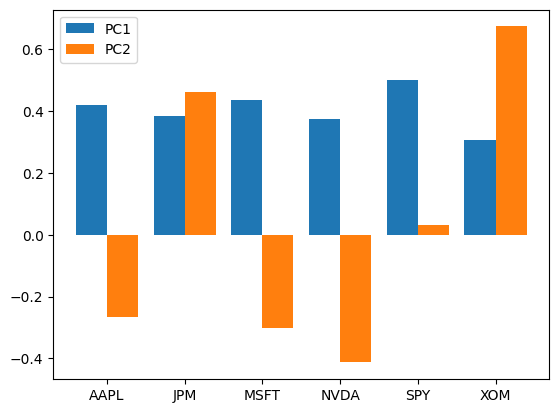

In [62]:
w, x = 0.4, np.arange(len(pca_loadings))

plt.bar(x - w/2, pca_loadings['PC1'], w, label='PC1')
plt.bar(x + w/2, pca_loadings['PC2'], w, label='PC2')
plt.xticks(range(6), pca_loadings.index)
plt.legend()
plt.show()

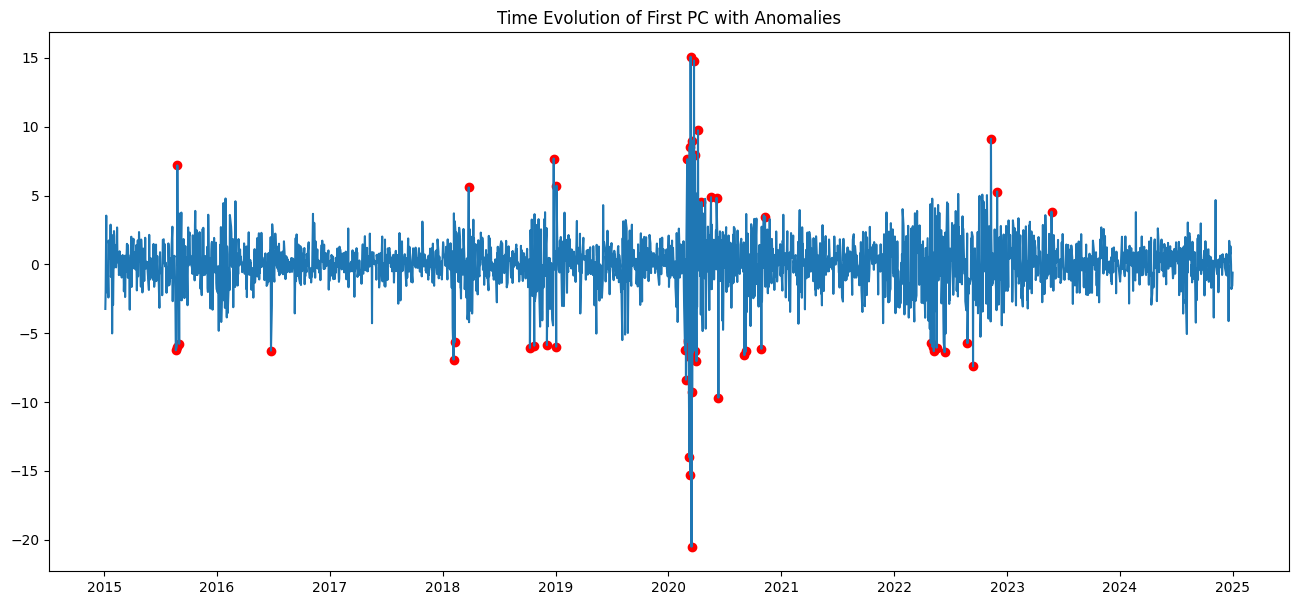

In [63]:
plt.figure(figsize=(16, 7))
plt.plot(pca_df.index, pca_df['PC1'])
plt.scatter(pca_df[pca_df['anomaly']].index,\
            pca_df[pca_df['anomaly']]['PC1'],\
            c = 'r')
plt.title("Time Evolution of First PC with Anomalies")
plt.show()

# Attempt with Hidden Markov Model

In [64]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 1.6 MB/s eta 0:00:00


In [66]:
spy_returns = log_returns['SPY']

In [67]:
Xspy = spy_returns.values.reshape(-1, 1)

In [68]:
from hmmlearn.hmm import GaussianHMM

In [79]:
hmm = GaussianHMM(
    n_components=3,
    n_iter=1000,
    random_state=42
)

In [80]:
hmm.fit(Xspy)

GaussianHMM(n_components=3, n_iter=1000, random_state=42)

In [81]:
hidden_states = hmm.predict(Xspy)

In [82]:
regime_df = pd.DataFrame({
    "returns": spy_returns,
    "state": hidden_states
}, index=spy_returns.index)

In [83]:
regime_df.head()

,returns,state
Date,,
2015-01-05,-0.018224,2
2015-01-06,-0.009463,2
2015-01-07,0.012384,2
2015-01-08,0.017590,2
2015-01-09,-0.008046,0


In [84]:
regime_summary = (
    regime_df
    .groupby("state")
    ["returns"]
    .agg([
        "mean",
        "std",
        "count"
    ])
)

In [85]:
print(regime_summary)

           mean       std  count
state                           
0      0.001261  0.006898   1032
1      0.000749  0.007472   1034
2     -0.001900  0.021225    449


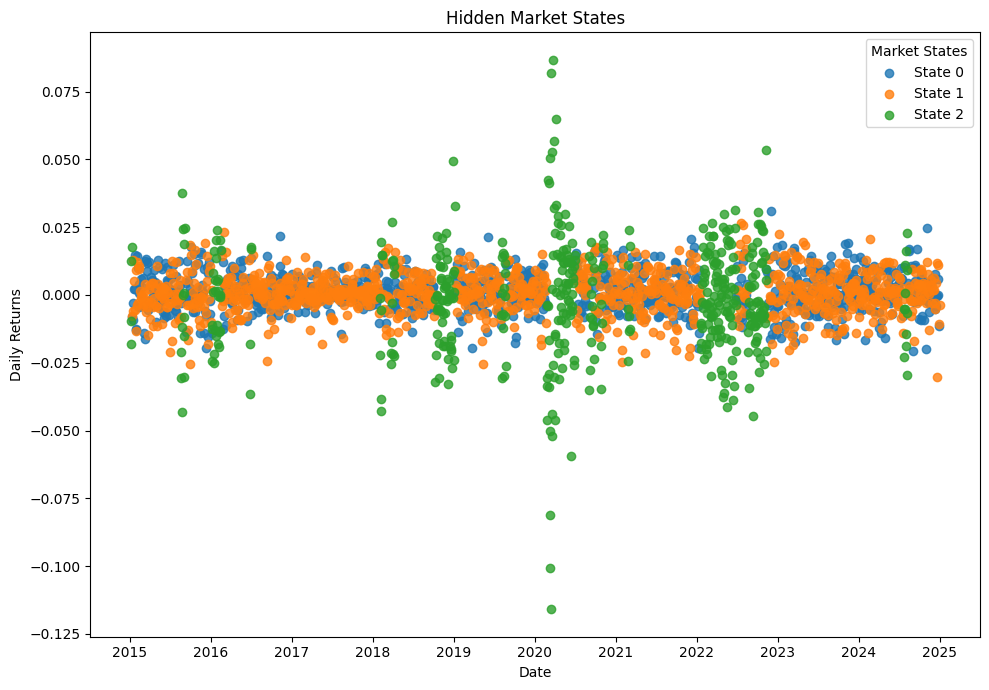

In [89]:
plt.figure(figsize=(10, 7))

for state in sorted(regime_df["state"].unique()):
    mask = regime_df["state"] == state

    plt.scatter(
        x=regime_df.index[mask],
        y=spy_returns[mask],
        label=f"State {state}",
        alpha=0.8
    )

plt.title("Hidden Market States")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.legend(title="Market States")
plt.tight_layout()
plt.show()

### Overlay of Regimes on SPY Prices

In [91]:
spy_prices = close_prices["SPY"]

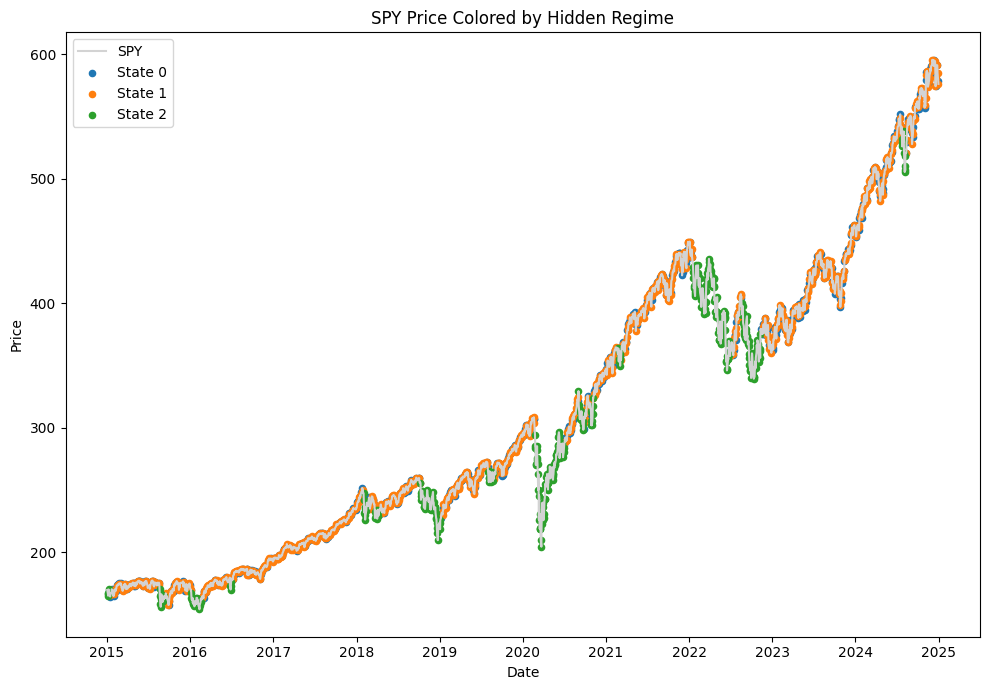

In [95]:
plt.figure(figsize=(10, 7))

plt.plot(
    spy_prices.index,
    spy_prices,
    label="SPY",
    color="lightgray"
)

for state in sorted(regime_df["state"].unique()):
    mask = regime_df["state"] == state
    state_indices = regime_df.index[mask]

    plt.scatter(
        x=state_indices,
        y=spy_prices.loc[state_indices],
        label=f"State {state}",
        s=20
    )

plt.title("SPY Price Colored by Hidden Regime")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [98]:
transition_matrix = pd.DataFrame(hmm.transmat_)

In [99]:
print(transition_matrix)

          0         1         2
0  0.003133  0.996856  0.000012
1  0.962803  0.014110  0.023087
2  0.035448  0.016965  0.947587


## Crisis Regime

In [100]:
state_volatility = regime_df.groupby("state")["returns"].std()

In [101]:
crisis_state = state_volatility.idxmax()

In [102]:
print(crisis_state)

2


In [103]:
crisis_days = regime_df[regime_df["state"] == crisis_state]

In [104]:
crisis_days

,returns,state
Date,,
2015-01-05,-0.018224,2
2015-01-06,-0.009463,2
2015-01-07,0.012384,2
2015-01-08,0.017590,2
2015-08-20,-0.021102,2
...,...,...
2024-08-02,-0.018794,2
2024-08-05,-0.029556,2
2024-08-06,0.009177,2
